# 1. First I import all necessary libraries.

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score



# 2. Next I load the datasets and take a peek.

In [ ]:
# Load the dataset
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# Preview the dataset
train_data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,label,id
0,3031,38,8,192,40,30,220,223,138,1176,...,0,0,0,0,0,0,0,0,2,255258
1,2717,66,14,384,-19,927,233,211,108,2452,...,0,0,0,0,0,0,0,0,2,158435
2,3172,24,9,300,27,2389,215,220,141,2408,...,0,0,0,0,0,0,0,0,1,204891
3,3089,67,2,285,-37,2424,221,235,151,1745,...,0,0,0,0,0,0,0,0,2,365229
4,2569,22,20,216,87,1095,204,194,121,1506,...,0,0,0,0,0,0,0,0,2,562782


# 3. Data Exploration
## Here I take a deeper look into the data sets by:
  * Checeking for any misssing values
  * Exploring the distribution in the target variable
  * Getting a summary of the dataset
  * Checking for any correlated features

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


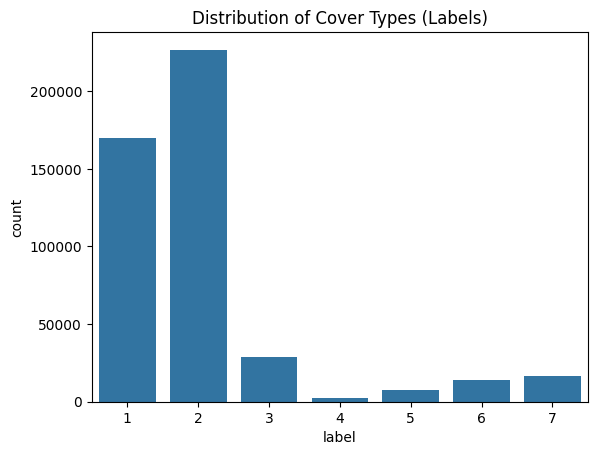

           Elevation         Aspect          Slope  \
count  464809.000000  464809.000000  464809.000000   
mean     2959.628663     155.778485      14.101696   
std       279.823965     111.899874       7.489081   
min      1859.000000       0.000000       0.000000   
25%      2810.000000      58.000000       9.000000   
50%      2996.000000     127.000000      13.000000   
75%      3163.000000     261.000000      18.000000   
max      3858.000000     360.000000      66.000000   

       Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  \
count                     464809.000000                   464809.000000   
mean                         269.369883                       46.467265   
std                          212.433304                       58.309570   
min                            0.000000                     -173.000000   
25%                          108.000000                        7.000000   
50%                          218.000000                       3

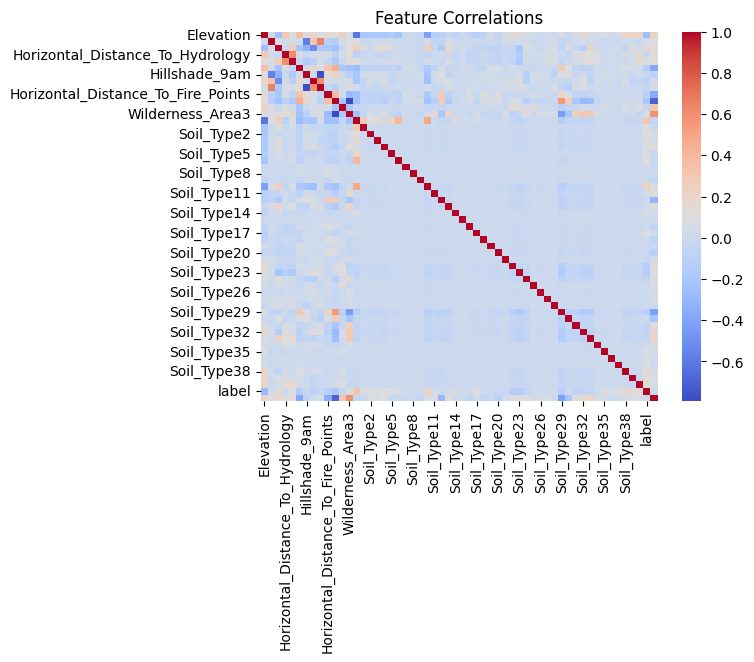

                                    Elevation    Aspect     Slope  \
Elevation                            1.000000  0.015429 -0.241814   
Aspect                               0.015429  1.000000  0.079211   
Slope                               -0.241814  0.079211  1.000000   
Horizontal_Distance_To_Hydrology     0.307182  0.016766 -0.010004   
Vertical_Distance_To_Hydrology       0.094671  0.069854  0.276074   
Horizontal_Distance_To_Roadways      0.364728  0.024650 -0.215562   
Hillshade_9am                        0.112021 -0.579766 -0.326979   
Hillshade_Noon                       0.205218  0.335857 -0.525606   
Hillshade_3pm                        0.058645  0.646649 -0.175162   
Horizontal_Distance_To_Fire_Points   0.147379 -0.109906 -0.186161   
Wilderness_Area1                     0.131011 -0.140891 -0.235310   
Wilderness_Area2                     0.238326  0.056234 -0.035483   
Wilderness_Area3                     0.066645  0.075586  0.126654   
Wilderness_Area4                  

In [ ]:
# Check for missing values
print(train_data.isnull().sum())

# Explore target variable distribution
sns.countplot(x='label', data=train_data)
plt.title("Distribution of Cover Types (Labels)")
plt.show()

# Summarize the dataset
print(train_data.describe())
print(train_data.info())

# Check correlations
correlation_matrix = train_data.corr()
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()
print(correlation_matrix)

# Data Exploration Cont'd.
## Based on the above outputs I have decerned the following:
   * There are no missing values in the dataset
   * The features with the highest correlation to 'label' were:
     * Wilderness_Area1: Absoulte Correlation = 0.0693393
     * Wilderness_Area3: Absolute Correlation = 0.591935
     * Wilderness_Area2: Absolute Correlation = 0.311783
     * Horizontal_Distance_To_Roadways: Absolute Correlation = 0.382894
     * Horizontal_Distance_To_Fire_Points: Absolute Correlation = 0.368299
     * Soil_Type29: Absolute Correlation = 0.424053

## The above correlations are helpfull as they tell me which feautures will contribute the most concenring variance in the model. However, I am still intereted in pairwise correlations so I know which features are redunant as well (i.e., avoid issues with multicoliniarity).

Pairwise Correlation Matrix:
                                    Elevation    Aspect     Slope  \
Elevation                            1.000000  0.016936 -0.246216   
Aspect                               0.016936  1.000000  0.076806   
Slope                               -0.246216  0.076806  1.000000   
Horizontal_Distance_To_Hydrology     0.302446  0.019813 -0.013018   
Vertical_Distance_To_Hydrology       0.087844  0.072094  0.270582   
Horizontal_Distance_To_Roadways      0.368858  0.026985 -0.217319   
Hillshade_9am                        0.112815 -0.577303 -0.328079   
Hillshade_Noon                       0.208521  0.337062 -0.532123   
Hillshade_3pm                        0.061142  0.648124 -0.178627   
Horizontal_Distance_To_Fire_Points   0.150565 -0.106276 -0.183655   
Wilderness_Area1                     0.135133 -0.137061 -0.231640   
Wilderness_Area2                     0.237515  0.054997 -0.039340   
Wilderness_Area3                     0.066172  0.072180  0.121696   
Wilde

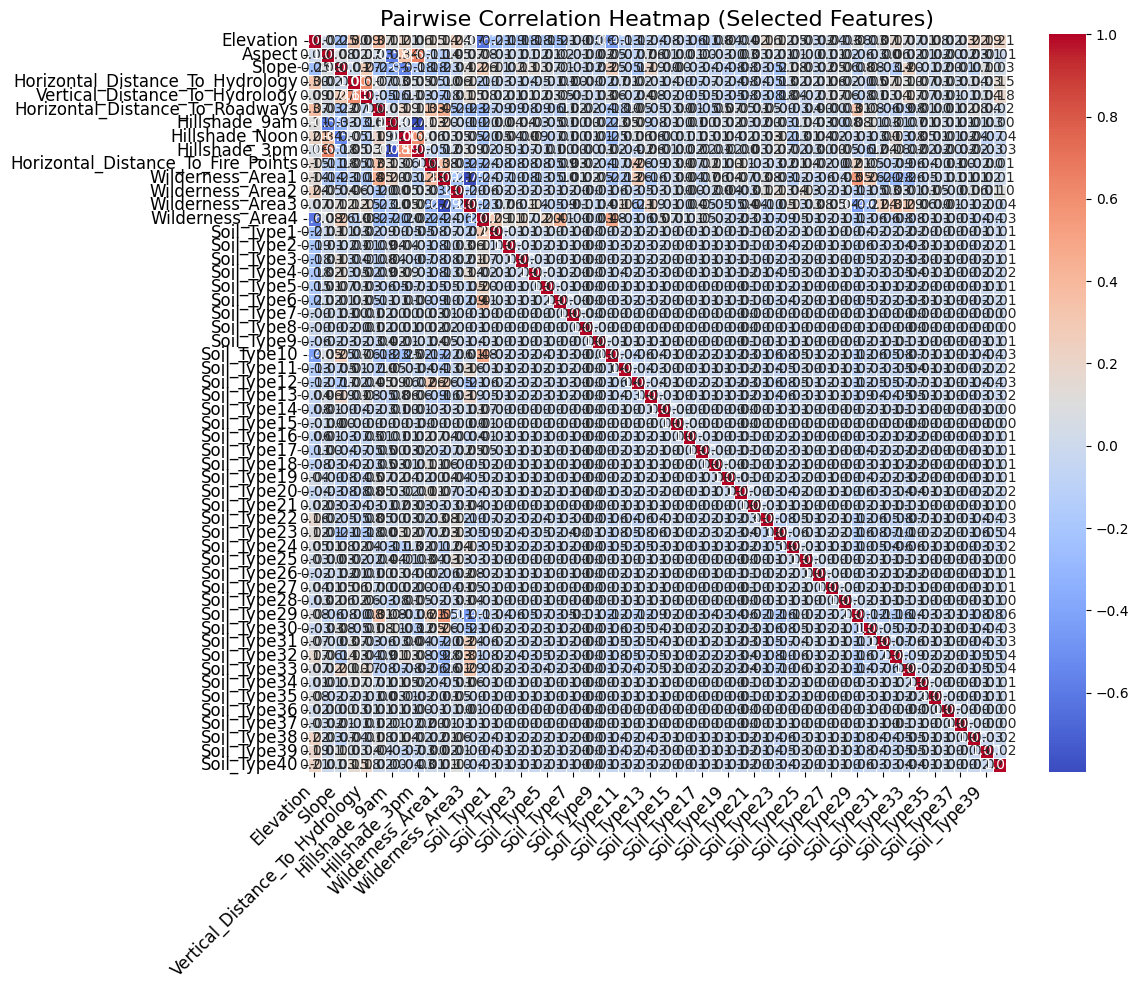


Highly Correlated Feature Pairs (|r| >= 0.9):
No pairs found with correlation |r| >= 0.9.


In [ ]:
# Here I selected all features that I wanted to check for pairwise correlations excluding 'id' and 'label'
selected_features = [col for col in test_data.columns if col not in ['id', 'label']]

# Then I compute the pairwise correlation matrix for the selected features
pairwise_correlation_matrix = test_data[selected_features].corr()

# Here I printed the pairwise correlation matrix
print("Pairwise Correlation Matrix:")
print(pairwise_correlation_matrix)

# Here I produced a visual representation of the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pairwise_correlation_matrix,
            annot=True, fmt=".2f", cmap="coolwarm",
            cbar=True, linewidths=0.5, annot_kws={"size": 10})
plt.title("Pairwise Correlation Heatmap (Selected Features)", fontsize=16)

# Here I rotated the labels to avoid overlap and make them readable(still has overlap though!)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

# Next, I  identified the highly correlated feature pairs (threshold >= 0.9, excluding diagonal)
threshold = 0.9
highly_correlated_pairs = [
    (pairwise_correlation_matrix.index[i], pairwise_correlation_matrix.columns[j])
    for i in range(len(pairwise_correlation_matrix))
    for j in range(len(pairwise_correlation_matrix))
    if (i != j) and (abs(pairwise_correlation_matrix.iloc[i, j]) >= threshold)
]

# Print highly correlated feature pairs
print("\nHighly Correlated Feature Pairs (|r| >= 0.9):")
if highly_correlated_pairs:
    for pair in highly_correlated_pairs:
        print(f"{pair[0]} and {pair[1]}")
else:
    print("No pairs found with correlation |r| >= 0.9.")



# 4. Data Preprocessing and Feature Engineering
## During the data exploration process I noticed that all catagorical data appears to already be one-hot encoded thus this is not necessary. Below I will:
   * Based on the correlation matrices I intitially ran the models using only the features with the highest absolute correlations to 'label' thus reducing dimentionality(see Data Exploration Cont'd markdown). However the accuracy rates were abismol so I decided to proceed with all features.
   * Dropped  'label' and 'id' columns in the training set.
   * Saved 'id' in the test set using 'pop'. Id will be needed later when it is time to generalize the highest perfroming model on the full test set and deploy the submision.csv.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Here I saved 'id' columns for later use
train_ids = train_data.pop('id')
test_ids = test_data.pop('id')

# Again I decided to Use all features for better model accuracy
X = train_data.drop(columns=['label'])
y = train_data['label']
X_test = test_data

# Here I split the dataset into training and validation sets (80/20 split, stratified by 'label')
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# I scaled the train, test and validation sets using standard scaler
scaler = StandardScaler()

# Then I fit and transformed the scaler on training data, validation and test data
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)




# 5. Model training using the preprocessing pipeline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time

# Logistic Regression
start_time = time.time()

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

y_val_pred = logistic_model.predict(X_val_scaled)

logistic_acc = accuracy_score(y_val, y_val_pred)
logistic_f1 = f1_score(y_val, y_val_pred, average='macro')
elapsed_time = time.time() - start_time

print("Logistic Regression Results")
print(f"Accuracy: {logistic_acc:.4f}")
print(f"Macro F1-Score: {logistic_f1:.4f}")
print(f"Training Time: {elapsed_time:.2f} seconds")


Logistic Regression Results
Accuracy: 0.7268
Macro F1-Score: 0.5313
Training Time: 28.05 seconds


In [ ]:
from sklearn.linear_model import Perceptron

# Perceptron
start_time = time.time()

perceptron_model = Perceptron(max_iter=1000, random_state=42)
perceptron_model.fit(X_train_scaled, y_train)

y_val_pred = perceptron_model.predict(X_val_scaled)

perceptron_acc = accuracy_score(y_val, y_val_pred)
perceptron_f1 = f1_score(y_val, y_val_pred, average='macro')
elapsed_time = time.time() - start_time

print("Perceptron Results")
print(f"Accuracy: {perceptron_acc:.4f}")
print(f"Macro F1-Score: {perceptron_f1:.4f}")
print(f"Training Time: {elapsed_time:.2f} seconds")



Perceptron Results
Accuracy: 0.6080
Macro F1-Score: 0.4017
Training Time: 5.26 seconds


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# K-Nearest Neighbors
start_time = time.time()

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_val_pred = knn_model.predict(X_val_scaled)

knn_acc = accuracy_score(y_val, y_val_pred)
knn_f1 = f1_score(y_val, y_val_pred, average='macro')
elapsed_time = time.time() - start_time

print("KNN Results")
print(f"Accuracy: {knn_acc:.4f}")
print(f"Macro F1-Score: {knn_f1:.4f}")
print(f"Training Time: {elapsed_time:.2f} seconds")




KNN Results
Accuracy: 0.9224
Macro F1-Score: 0.8677
Training Time: 49.80 seconds


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
start_time = time.time()

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train_scaled, y_train)

y_val_pred = random_forest_model.predict(X_val_scaled)

rf_acc = accuracy_score(y_val, y_val_pred)
rf_f1 = f1_score(y_val, y_val_pred, average='macro')
elapsed_time = time.time() - start_time

print("Random Forest Results")
print(f"Accuracy: {rf_acc:.4f}")
print(f"Macro F1-Score: {rf_f1:.4f}")
print(f"Training Time: {elapsed_time:.2f} seconds")


Random Forest Results
Accuracy: 0.9510
Macro F1-Score: 0.9208
Training Time: 87.92 seconds


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree
start_time = time.time()

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_scaled, y_train)

y_val_pred = decision_tree_model.predict(X_val_scaled)

dt_acc = accuracy_score(y_val, y_val_pred)
dt_f1 = f1_score(y_val, y_val_pred, average='macro')
elapsed_time = time.time() - start_time

print("Decision Tree Results")
print(f"Accuracy: {dt_acc:.4f}")
print(f"Macro F1-Score: {dt_f1:.4f}")
print(f"Training Time: {elapsed_time:.2f} seconds")



Decision Tree Results
Accuracy: 0.9329
Macro F1-Score: 0.8953
Training Time: 6.10 seconds


In [ ]:
import time
from sklearn.svm import LinearSVC  # I had to use the LinearSVC for faster convergence with a linear kernel
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

# Here I scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Support Vector Machine (using LinearSVC)
start_time = time.time()

svm_model = LinearSVC(C=0.1, random_state=42, max_iter=5000, tol=1e-3)
svm_model.fit(X_train_scaled, y_train)

y_val_pred = svm_model.predict(X_val_scaled)

svm_acc = accuracy_score(y_val, y_val_pred)
svm_f1 = f1_score(y_val, y_val_pred, average='macro')
elapsed_time = time.time() - start_time

print("SVM Results")
print(f"Accuracy: {svm_acc:.4f}")
print(f"Macro F1-Score: {svm_f1:.4f}")
print(f"Training Time: {elapsed_time:.2f} seconds")




SVM Results
Accuracy: 0.7147
Macro F1-Score: 0.4549
Training Time: 63.59 seconds


In [ ]:
# Prior to training the final mdoel I had to convert the scaled data (NumPy arrays) back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Random Forest performed the best so I assinged it to the variable best_model
best_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Next I trained the Random Forest classifier on the full dataset
X_full_train = pd.concat([X_train_scaled, X_val_scaled], axis=0)
y_full_train = pd.concat([y_train, y_val], axis=0)

# Next I fit the model on the full training data
best_model.fit(X_full_train, y_full_train)

# Then I made predictions on the test set
y_test_pred = best_model.predict(X_test_scaled)

# Next I prepared submission DataFrame using 'test_ids' as it was saved earlier during preprocssing using 'pop'
submission = pd.DataFrame({
    'id': test_ids,  # Use the saved 'id' values
    'label': y_test_pred
})

# Finally, I saved the submission as a CSV file
submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created successfully!")




Submission file 'submission.csv' created successfully!


# 6. Model Training and final decision
   ## The Final model selected to train and subsequently deploy was the Random Forest Model here were its metrics:
 ## Random Forest Results
* Accuracy: 0.9510
* Macro F1-Score: 0.9208
* Training Time: 87.92 seconds

  ## The next best perfroming model concerning accraucy and Macro F1-Score was Decsion Tree here were its metrics:

## Decision Tree Results
* Accuracy: 0.9329
* Macro F1-Score: 0.8953
* Training Time: 6.10 seconds

## Notes on Conversions
* I developed in google colab, this project required more computing power than the standard version as runtimes were too long.
* The SVC classifier was not converging so I experimented with various kernels and landed on the linear kernel.
* The Logestic Regression initially was perfroming a lot poorer than the final out put, however, I adjusted the following hyperparameters:played with the max_inter landed on 1000.
